In [6]:
import pandas 

data = pandas.read_csv("datasets/supermarket_data.csv")
data

,Invoice ID,city,customertype,gender,product,itemprice,quantity,total,date,time,payment,customersalary,rating
0,750-67-8428,Nairobi,Member,Female,Health and beauty,74.69,7,548.9715,1/5/2019,13:08,MPESA,26.1415,9.1
1,226-31-3081,Nakuru,Normal,Female,Electronic accessories,15.28,5,80.2200,3/8/2019,10:29,Cash,3.8200,9.6
2,631-41-3108,Nairobi,Normal,Female,Home and lifestyle,46.33,7,340.5255,3/3/2019,13:23,Credit card,16.2155,7.4
3,123-19-1176,Nairobi,Member,Female,Health and beauty,58.22,8,489.0480,1/27/2019,20:33,MPESA,23.2880,8.4
4,373-73-7910,Nairobi,Normal,Female,Health and beauty,86.31,7,634.3785,2/8/2019,10:37,MPESA,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,233-67-5758,Nakuru,Normal,Male,Health and beauty,40.35,1,42.3675,1/29/2019,13:46,MPESA,2.0175,6.2
997,303-96-2227,Mombasa,Normal,Female,Home and lifestyle,97.38,10,1022.4900,3/2/2019,17:16,MPESA,48.6900,4.4
998,727-02-1313,Nairobi,Member,Male,Food and beverages,31.84,1,33.4320,2/9/2019,13:22,Cash,1.5920,7.7
999,347-56-2442,Nairobi,Normal,Male,Home and lifestyle,65.82,1,69.1110,2/22/2019,15:33,Cash,3.2910,4.1


In [7]:
# Use the Describe function
data.describe()

,itemprice,quantity,total,customersalary,rating
count,998.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,55.686523,5.505495,322.739927,15.368568,6.972527
std,26.538665,2.925444,245.867115,11.707958,1.717729
min,10.080000,1.000000,10.678500,0.508500,4.000000
25%,32.825000,3.000000,122.524500,5.834500,5.500000
50%,55.230000,5.000000,253.680000,12.080000,7.000000
75%,78.040000,8.000000,471.030000,22.430000,8.500000
max,99.960000,10.000000,1042.650000,49.650000,10.000000


In [8]:
# we have noticed that the column itemprice column, contains 3 empty slots.

# We need to fill these empty slots with a value and in this case we shall fill with the mean of the column

data["itemprice"] = data["itemprice"].fillna(55)

 

# describe the data again

data.describe()

,itemprice,quantity,total,customersalary,rating
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,55.684466,5.505495,322.739927,15.368568,6.972527
std,26.498854,2.925444,245.867115,11.707958,1.717729
min,10.080000,1.000000,10.678500,0.508500,4.000000
25%,32.900000,3.000000,122.524500,5.834500,5.500000
50%,55.040000,5.000000,253.680000,12.080000,7.000000
75%,77.950000,8.000000,471.030000,22.430000,8.500000
max,99.960000,10.000000,1042.650000,49.650000,10.000000


In [9]:
data.groupby("gender").size()

gender
Female    625
Male      376
dtype: int64

In [16]:
# compining mulitiple columns
data.groupby(["city", "payment", "gender"]).size()

city     payment      gender
Mombasa  Cash         Female     41
                      Male       32
         Credit card  Female     58
                      Male       25
         MPESA        Female     93
                      Male       51
Nairobi  Cash         Female     66
                      Male       52
         Credit card  Female     57
                      Male       41
         MPESA        Female    107
                      Male       72
Nakuru   Cash         Female     52
                      Male       32
         Credit card  Female     56
                      Male       18
         MPESA        Female     95
                      Male       53
dtype: int64

In [10]:
# Import the module
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\USER\AppData\Local\Temp\ipykernel_15224\409722840.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="gender", data=data, palette="spring")


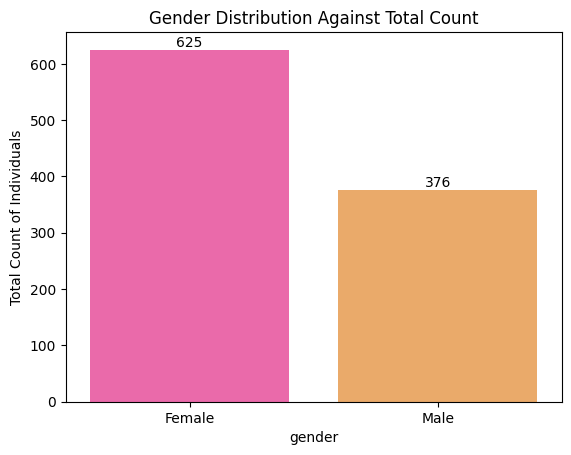

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Create the plot and assign it to 'ax'
ax = sns.countplot(x="gender", data=data, palette="spring")
# 2. Add labels to each bar container
for container in ax.containers:
    ax.bar_label(container)
# 3. Rest of your formatting
plt.title("Gender Distribution Against Total Count")
plt.ylabel("Total Count of Individuals")
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_15224\3582388945.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="product", data=data, palette="winter")


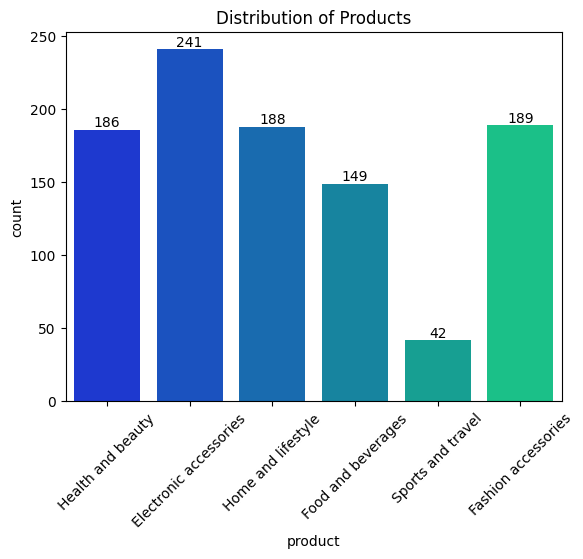

In [17]:
# Import Seaborn for statistical visualization
import seaborn as sns

# Import Matplotlib for plotting control and display
import matplotlib.pyplot as plt

# Create a count plot (bar chart) showing frequency of each product in the dataset
# x="product" means we are counting occurrences of each product category
ax = sns.countplot(x="product", data=data, palette="winter")

# Loop through each bar (patch) in the plot
for p in ax.patches:
    
    # Annotate (write) the exact count value on top of each bar
    ax.annotate(
        str(int(p.get_height())),   # Convert bar height (count) to integer string
        (p.get_x() + p.get_width() / 2., p.get_height()),  # Position: center of bar top
        ha='center',   # Horizontal alignment: center text on bar
        va='bottom'    # Vertical alignment: place text just above bar
    )

# Rotate x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# Add title to the plot
plt.title("Distribution of Products")

# Display the final plot
plt.show()

# -------------------- EXTRA NOTES --------------------
# ax.patches → contains all bars created by the countplot
# p.get_height() → returns the height of each bar (i.e., count value)
# ax.annotate() → used to place text (numbers) on the chart

<Axes: xlabel='gender', ylabel='count'>

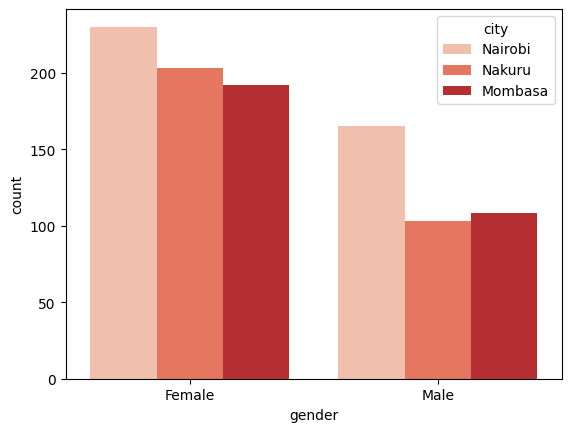

In [13]:
# Below is countplot that has two columns
sns.countplot(x="gender", hue="city", palette="Reds", data=data)

<Axes: >

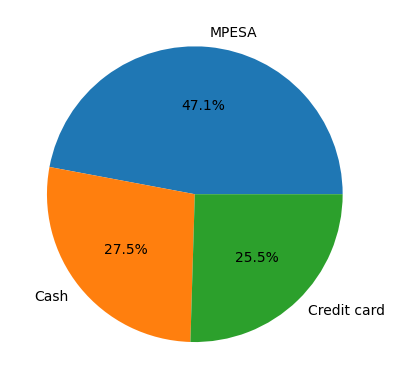

In [14]:
# below is a pieplot

data["payment"].value_counts().plot.pie(autopct='%1.1f%%')